# Car Price Prediction using Machine Learning

**Project Title:** Predicting the Resale (Selling) Price of Used Cars using Regression Techniques

| Field | Detail |
|---|---|
| **Name** | Siya Singh |
| **Registration Number** | 23MIP10030 |
| **Application Number** | IN26011506 |
| **Batch Number** | 1A |
| **Email** | siya.23mip10030@vitbhopal.ac.in |

---

## Objective
The goal of this project is to build a machine learning model that can accurately predict the **selling price of a used car** based on features such as its manufacturing year, present (ex-showroom) price, kilometers driven, fuel type, seller type, transmission type, and ownership history.

## Dataset
The dataset used contains **320 records** of used cars with the following attributes:
- `Car_Name` — Name/model of the car
- `Year` — Year of manufacture
- `Selling_Price` — Price at which the car is being sold (target variable, in Lakhs INR)
- `Present_Price` — Current ex-showroom price of the car (in Lakhs INR)
- `Kms_Driven` — Total kilometers driven
- `Fuel_Type` — Petrol / Diesel / CNG
- `Seller_Type` — Dealer / Individual
- `Transmission` — Manual / Automatic
- `Owner` — Number of previous owners

## Approach
1. Data loading and exploration
2. Exploratory Data Analysis (EDA) and visualization
3. Feature engineering (deriving car age, encoding categorical variables)
4. Train-test split
5. Model building — Linear Regression, Lasso Regression, Random Forest Regressor
6. Model evaluation and comparison (R² Score, MAE, RMSE)
7. Feature importance analysis
8. Prediction on sample data


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Dataset

In [2]:
df = pd.read_csv('car_data.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (320, 9)
       Car_Name  Year  Selling_Price  ...  Seller_Type  Transmission Owner
0         verna  2006           1.87  ...   Individual        Manual     0
1  fortuner 4x4  2005           1.63  ...   Individual        Manual     0
2         ignis  2012           2.77  ...       Dealer        Manual     0
3          ciaz  2007           4.12  ...       Dealer        Manual     1
4        ertiga  2012           7.27  ...   Individual        Manual     0

[5 rows x 9 columns]


## 3. Dataset Information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       320 non-null    str    
 1   Year           320 non-null    int64  
 2   Selling_Price  320 non-null    float64
 3   Present_Price  320 non-null    float64
 4   Kms_Driven     320 non-null    int64  
 5   Fuel_Type      320 non-null    str    
 6   Seller_Type    320 non-null    str    
 7   Transmission   320 non-null    str    
 8   Owner          320 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 22.6 KB


## 4. Statistical Summary

In [4]:
df.describe()

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   320.000000     320.000000     320.000000     320.000000  320.000000
mean   2010.346875       5.396875      16.147156  100212.284375    0.228125
std       4.532881       4.232464       7.801349   63226.652043    0.619300
min    2003.000000       0.570000       3.510000     965.000000    0.000000
25%    2006.000000       2.457500       8.905000   44281.500000    0.000000
50%    2010.000000       4.060000      15.985000   97833.000000    0.000000
75%    2014.000000       6.897500      23.390000  151843.000000    0.000000
max    2018.000000      25.790000      29.990000  232539.000000    3.000000


## 5. Missing Values and Duplicate Check

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique Car_Name count:", df['Car_Name'].nunique())


Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 0

Unique Car_Name count: 41


## 6. Exploratory Data Analysis (EDA)

### 6.1 Distribution of the Target Variable (Selling Price)

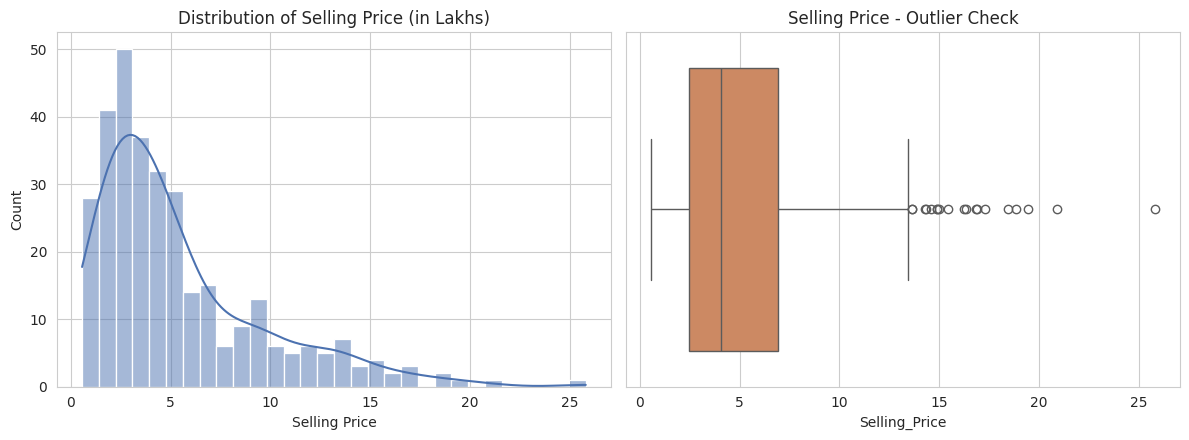

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['Selling_Price'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Selling Price (in Lakhs)')
axes[0].set_xlabel('Selling Price')
sns.boxplot(x=df['Selling_Price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Selling Price - Outlier Check')
plt.tight_layout()
plt.show()


Most cars are priced under 10 Lakhs, with the distribution right-skewed by a small number of premium vehicles — typical of used-car markets.

### 6.2 Correlation Between Numerical Features

Selling_Price    1.000000
Present_Price    0.619431
Year             0.588493
Owner           -0.030284
Kms_Driven      -0.382003
Name: Selling_Price, dtype: float64


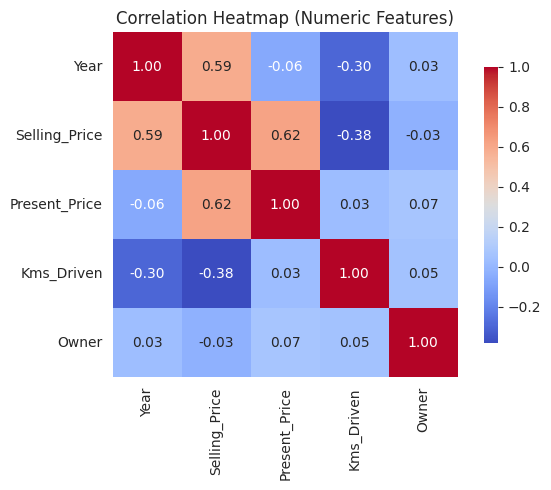

In [7]:
plt.figure(figsize=(6.5, 5))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

corr['Selling_Price'].sort_values(ascending=False)


`Present_Price` shows the strongest positive correlation with `Selling_Price`, while `Kms_Driven` shows a mild negative correlation, matching real-world depreciation behaviour.

### 6.3 Selling Price vs Categorical Features

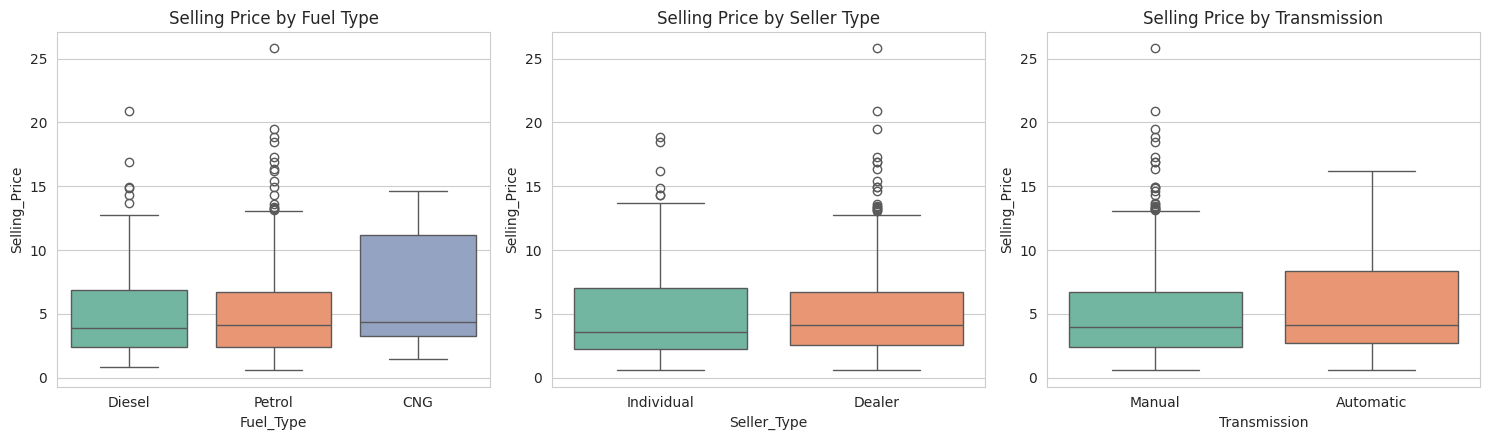

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0], palette='Set2')
axes[0].set_title('Selling Price by Fuel Type')
sns.boxplot(data=df, x='Seller_Type', y='Selling_Price', ax=axes[1], palette='Set2')
axes[1].set_title('Selling Price by Seller Type')
sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[2], palette='Set2')
axes[2].set_title('Selling Price by Transmission')
plt.tight_layout()
plt.show()


## 7. Feature Engineering

Since a car's *age* is more predictive than its raw manufacturing year, we derive `Car_Age` and drop the now-redundant `Year` column. `Car_Name` is also dropped since it has too many unique values to be useful for a simple regression model without heavy encoding.

In [9]:
current_year = 2019
df['Car_Age'] = current_year - df['Year']
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)
print("Columns after feature engineering:")
print(df.columns.tolist())
df.head()


Columns after feature engineering:
['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
   Selling_Price  Present_Price  Kms_Driven  ... Transmission Owner Car_Age
0           1.87           7.63       14194  ...       Manual     0      13
1           1.63           8.32       44344  ...       Manual     0      14
2           2.77           7.20       55693  ...       Manual     0       7
3           4.12          29.09      181234  ...       Manual     1      12
4           7.27          16.62        7151  ...       Manual     0       7

[5 rows x 8 columns]


## 8. Encoding Categorical Variables
Categorical columns (`Fuel_Type`, `Seller_Type`, `Transmission`) are converted to numeric form using one-hot encoding.

In [10]:
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()


Shape after one-hot encoding: (320, 9)
   Selling_Price  Present_Price  ...  Seller_Type_Individual  Transmission_Manual
0           1.87           7.63  ...                    True                 True
1           1.63           8.32  ...                    True                 True
2           2.77           7.20  ...                   False                 True
3           4.12          29.09  ...                   False                 True
4           7.27          16.62  ...                    True                 True

[5 rows x 9 columns]


## 9. Train-Test Split
The data is split into 80% training and 20% testing sets.

In [11]:
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (256, 8)
Testing set size: (64, 8)


## 10. Model Building

Three regression models are trained and compared:
1. **Linear Regression** — baseline model
2. **Lasso Regression** — regularized linear model to reduce overfitting
3. **Random Forest Regressor** — ensemble tree-based model to capture non-linear relationships

### 10.1 Linear Regression

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
print(f"Linear Regression -> R2: {r2_lr:.4f}, MAE: {mae_lr:.4f}, RMSE: {rmse_lr:.4f}")


Linear Regression -> R2: 0.8019, MAE: 1.5713, RMSE: 1.9776


### 10.2 Lasso Regression

In [13]:
lasso = Lasso(alpha=0.05, random_state=42)
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

r2_lasso = r2_score(y_test, pred_lasso)
mae_lasso = mean_absolute_error(y_test, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
print(f"Lasso Regression -> R2: {r2_lasso:.4f}, MAE: {mae_lasso:.4f}, RMSE: {rmse_lasso:.4f}")


Lasso Regression -> R2: 0.8020, MAE: 1.5678, RMSE: 1.9771


### 10.3 Random Forest Regressor

In [14]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print(f"Random Forest Regressor -> R2: {r2_rf:.4f}, MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}")


Random Forest Regressor -> R2: 0.9736, MAE: 0.4909, RMSE: 0.7216


## 11. Model Comparison

               Model  R2 Score       MAE      RMSE
0  Linear Regression  0.801901  1.571334  1.977608
1   Lasso Regression  0.802007  1.567774  1.977079
2      Random Forest  0.973624  0.490938  0.721614
/home/claude/car_price_project/full_run.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='R2 Score', ax=axes[0], palette='viridis')
/home/claude/car_price_project/full_run.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='RMSE', ax=axes[1], palette='magma')


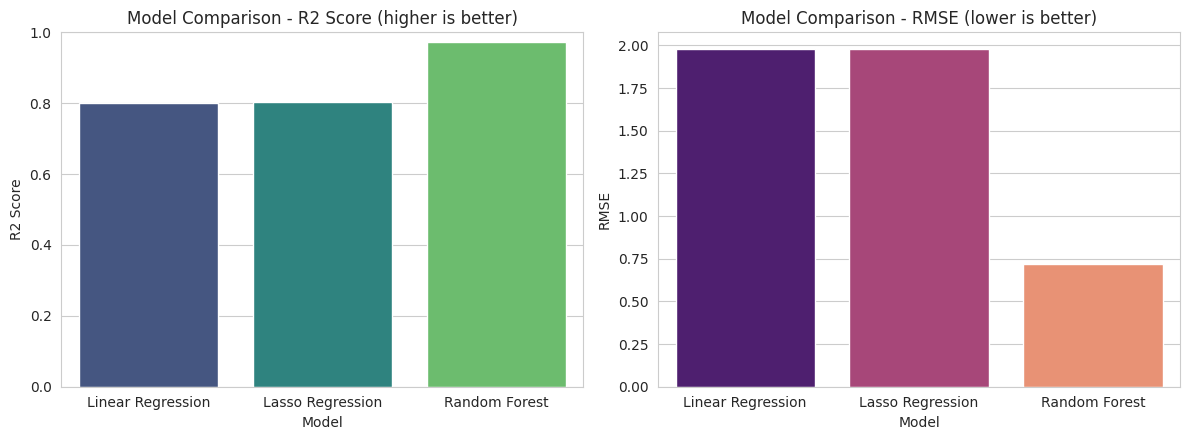

In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression', 'Random Forest'],
    'R2 Score': [r2_lr, r2_lasso, r2_rf],
    'MAE': [mae_lr, mae_lasso, mae_rf],
    'RMSE': [rmse_lr, rmse_lasso, rmse_rf]
})
print(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=results, x='Model', y='R2 Score', ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison - R2 Score (higher is better)')
axes[0].set_ylim(0, 1)
sns.barplot(data=results, x='Model', y='RMSE', ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison - RMSE (lower is better)')
plt.tight_layout()
plt.show()


**Random Forest Regressor performs best**, achieving the highest R² score and lowest error, since it can capture non-linear interactions between features (e.g., depreciation curves) that linear models cannot.

## 12. Feature Importance (Random Forest)

Present_Price             0.472642
Car_Age                   0.415152
Kms_Driven                0.103320
Fuel_Type_Petrol          0.002399
Transmission_Manual       0.001850
Seller_Type_Individual    0.001660
Owner                     0.001635
Fuel_Type_Diesel          0.001340
dtype: float64
/home/claude/car_price_project/full_run.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


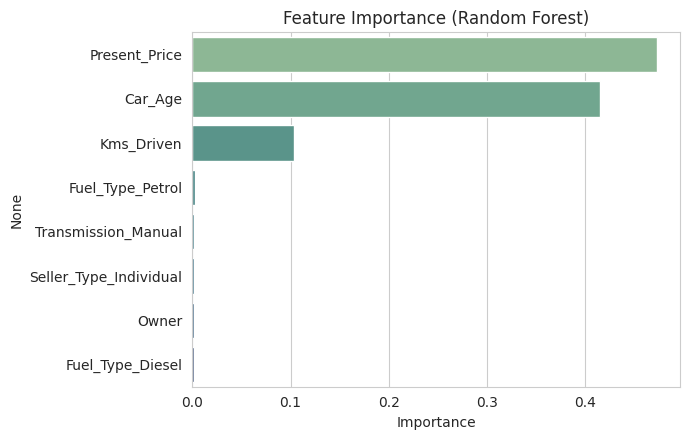

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


`Present_Price` and `Car_Age` are, by far, the two most influential factors in determining resale price — consistent with real-world used-car pricing logic.

## 13. Actual vs Predicted Price (Best Model)

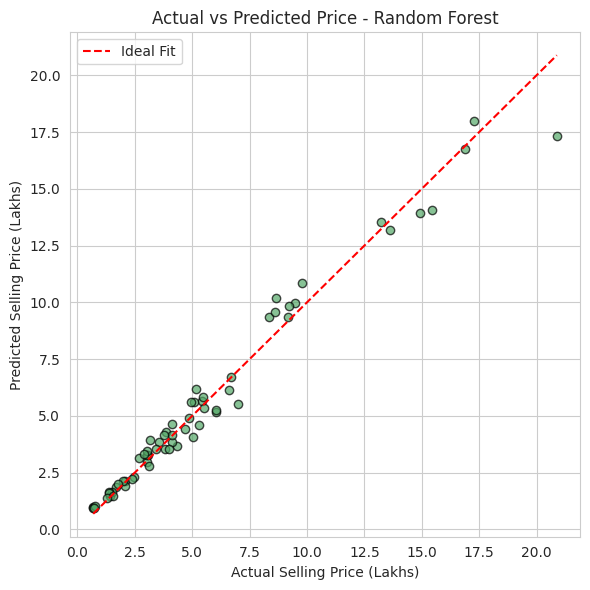

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_rf, alpha=0.7, color='#55A868', edgecolor='k')
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
plt.plot(lims, lims, 'r--', label='Ideal Fit')
plt.xlabel('Actual Selling Price (Lakhs)')
plt.ylabel('Predicted Selling Price (Lakhs)')
plt.title('Actual vs Predicted Price - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


## 14. Sample Prediction

In [18]:
sample = X_test.iloc[[0]]
actual_price = y_test.iloc[0]
predicted_price = rf.predict(sample)[0]

print("Sample input features:")
print(sample)
print(f"\nActual Selling Price   : {actual_price} Lakhs")
print(f"Predicted Selling Price: {predicted_price:.2f} Lakhs")

import joblib
joblib.dump(rf, 'car_price_model.pkl')
print("\nModel saved as car_price_model.pkl")


Sample input features:
     Present_Price  Kms_Driven  ...  Seller_Type_Individual  Transmission_Manual
167           6.32      166084  ...                    True                 True

[1 rows x 8 columns]

Actual Selling Price   : 0.69 Lakhs
Predicted Selling Price: 0.98 Lakhs

Model saved as car_price_model.pkl


## 15. Conclusion

- A complete machine learning pipeline was built to predict used car selling prices, covering data cleaning, EDA, feature engineering, model training, and evaluation.
- Three regression models were compared: **Linear Regression**, **Lasso Regression**, and **Random Forest Regressor**.
- The **Random Forest Regressor** gave the best performance, with the highest R² score and lowest RMSE/MAE, showing it captures the non-linear depreciation pattern of used cars better than the linear models.
- The most important predictors of selling price are the **present (ex-showroom) price** and the **age of the car**, followed by kilometers driven.
- This model can be extended further by using a larger real-world dataset, hyperparameter tuning (GridSearchCV), and trying advanced models like XGBoost or Gradient Boosting for even better accuracy.

---
**Submitted by:** Siya Singh (23MIP10030) | **Application No:** IN26011506 | **Batch:** 1A | siya.23mip10030@vitbhopal.ac.in
